In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\Lenovo\anaconda3\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
#Load the dataset
df = pd.read_csv("C:/Users/Lenovo/Desktop/ml_project/data/house_prices.csv")
#Basic info
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Property_ID    300 non-null    object
 1   Area           300 non-null    int64 
 2   Bedrooms       300 non-null    int64 
 3   Bathrooms      300 non-null    int64 
 4   Age            300 non-null    int64 
 5   Location       300 non-null    object
 6   Property_Type  300 non-null    object
 7   Price          300 non-null    int64 
dtypes: int64(5), object(3)
memory usage: 18.9+ KB


,Area,Bedrooms,Bathrooms,Age,Price
count,300.00000,300.000000,300.000000,300.000000,3.000000e+02
mean,2759.70000,3.033333,2.026667,25.000000,2.488366e+07
std,1297.68143,1.467219,0.792495,14.332646,1.266525e+07
min,520.00000,1.000000,1.000000,0.000000,3.695000e+06
25%,1675.75000,2.000000,1.000000,12.000000,1.527750e+07
50%,2738.00000,3.000000,2.000000,25.500000,2.236500e+07
75%,3801.25000,4.000000,3.000000,36.250000,3.460812e+07
max,4999.00000,5.000000,3.000000,49.000000,5.870000e+07


In [3]:
df['Location'].value_counts()

Suburb         105
Rural           98
City Center     97
Name: Location, dtype: int64

In [4]:
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].nunique())

Property_ID 300
Location 3
Property_Type 3


### Propertyid willnot play any role in model prediction. So it needtobe removed

In [5]:
df.drop("Property_ID", axis = 1, inplace =True)
df.head()

,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price
0,3712,4,3,36,Rural,House,22260000
1,1591,4,1,35,Suburb,House,16057500
2,1646,4,3,20,Rural,Villa,12730000
3,4814,1,2,13,City Center,Villa,50840000
4,800,4,2,38,Suburb,Apartment,10650000


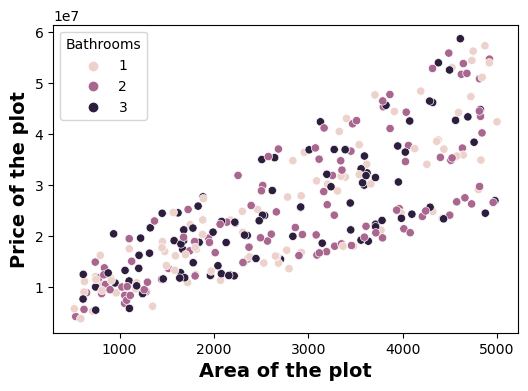

In [13]:
#Now see the relations of Area of plot to price
plt.figure(figsize = (6,4))
sns.scatterplot(x = 'Area', y= 'Price', data = df)
plt.xlabel("Area of the plot", fontsize = 14, fontweight = 'bold')
plt.ylabel("Price of the plot", fontsize = 14, fontweight = 'bold')
plt.show()

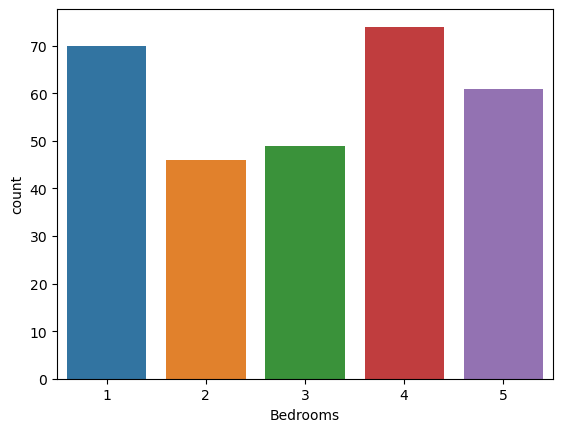

In [27]:
#Countplot of the bedrooms
sns.countplot(x="Bedrooms", data=df)
plt.show()

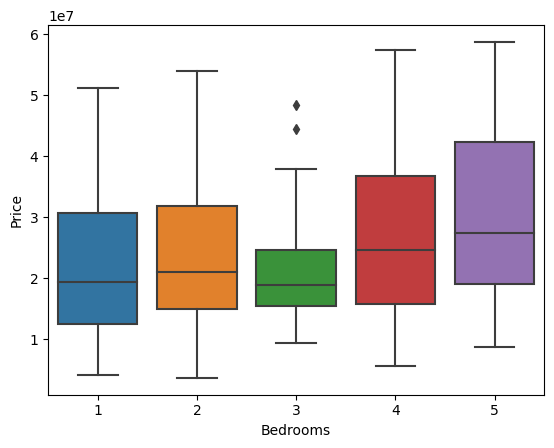

In [29]:
sns.boxplot(x="Bedrooms", y="Price", data=df)
plt.show()

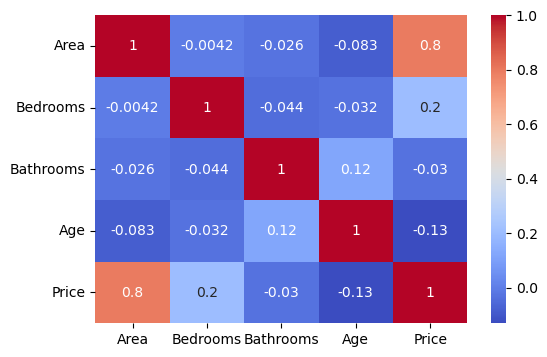

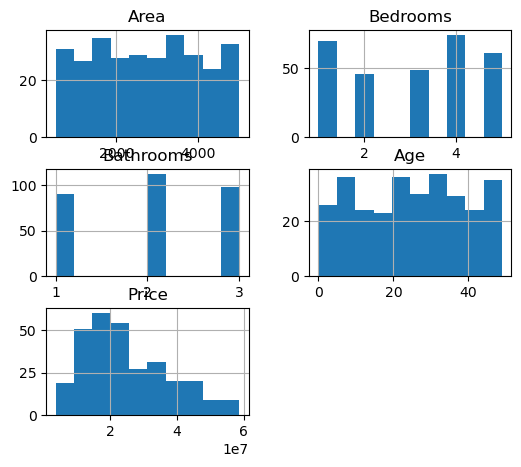

In [16]:
# Correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

# Distribution
df.hist(figsize=(6,5))
plt.show()

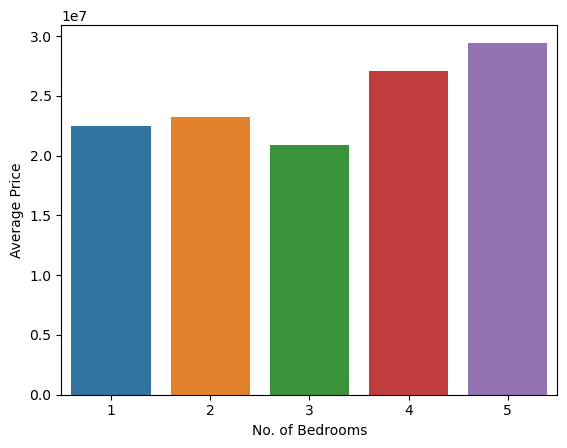

In [26]:
# Averge price variations by bedrooms
avg_price_bedrooms = df.groupby("Bedrooms")["Price"].mean().reset_index()
sns.barplot(x= 'Bedrooms', y = 'Price', data=avg_price_bedrooms)
plt.xlabel('No. of Bedrooms')
plt.ylabel("Average Price")
plt.show()

In [34]:
Avg_price_location=df.groupby("Location")["Price"].mean().sort_values()

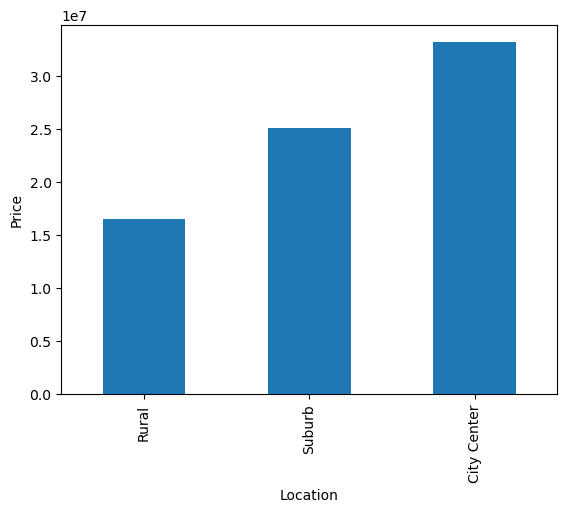

In [37]:
Avg_price_location.plot(kind='bar')
plt.xlabel("Location")
plt.ylabel("Price")
plt.show()